# **Visualização: Balanço Patrimonial e Preço**

In [32]:
from pandas import read_csv

def data(file, cnpj):

    # Nome do arquivo
    file = f"itr_cia_aberta_{file}_2011-2025.csv"

    # Caminho para o arquivo
    path = f"Q:\\financial_data_pipelines\\data\pipelines\\formulario_informacoes_trimestrais\\processed\\filter_columns\\{file}"

    df = read_csv(path, encoding="utf-8")

    # Selecionando dados de uma empresa especifica
    df = df[df["CNPJ_CIA"] == cnpj]

    # Selecionando informação atualizada
    df = df[df["ORDEM_EXERC"] == "ÚLTIMO"]
    return df
    

In [33]:
df_DRE_klbn = data("DRE_con", "89.637.490/0001-45")
df_DRE_klbn.tail(3)

,DT_REFER,DENOM_CIA,CNPJ_CIA,VERSAO,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
1921670,2025-06-30,KLABIN S.A.,89.637.490/0001-45,1,ÚLTIMO,2025-06-30,3.99.02.01,ON,0.0942,N
1921673,2025-06-30,KLABIN S.A.,89.637.490/0001-45,1,ÚLTIMO,2025-06-30,3.99.02.02,PN,0.1602,N
1921674,2025-06-30,KLABIN S.A.,89.637.490/0001-45,1,ÚLTIMO,2025-06-30,3.99.02.02,PN,0.0942,N


In [34]:
df_DRE_klbn_receita = df_DRE_klbn[df_DRE_klbn["CD_CONTA"] == "3.01"]
df_DRE_klbn_receita

,DT_REFER,DENOM_CIA,CNPJ_CIA,VERSAO,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
116619,2011-03-31,KLABIN S.A.,89.637.490/0001-45,2,ÚLTIMO,2011-03-31,3.01,Receita de Venda de Bens e/ou Serviços,957005.0,S
116688,2011-06-30,KLABIN S.A.,89.637.490/0001-45,1,ÚLTIMO,2011-06-30,3.01,Receita de Venda de Bens e/ou Serviços,1904452.0,S
116689,2011-06-30,KLABIN S.A.,89.637.490/0001-45,1,ÚLTIMO,2011-06-30,3.01,Receita de Venda de Bens e/ou Serviços,947447.0,S
116824,2011-09-30,KLABIN S.A.,89.637.490/0001-45,2,ÚLTIMO,2011-09-30,3.01,Receita de Venda de Bens e/ou Serviços,2895075.0,S
116825,2011-09-30,KLABIN S.A.,89.637.490/0001-45,2,ÚLTIMO,2011-09-30,3.01,Receita de Venda de Bens e/ou Serviços,990623.0,S
...,...,...,...,...,...,...,...,...,...,...
1826369,2024-09-30,KLABIN S.A.,89.637.490/0001-45,2,ÚLTIMO,2024-09-30,3.01,Receita de Venda de Bens e/ou Serviços,14377045.0,S
1826370,2024-09-30,KLABIN S.A.,89.637.490/0001-45,2,ÚLTIMO,2024-09-30,3.01,Receita de Venda de Bens e/ou Serviços,4998729.0,S
1921448,2025-03-31,KLABIN S.A.,89.637.490/0001-45,1,ÚLTIMO,2025-03-31,3.01,Receita de Venda de Bens e/ou Serviços,4858534.0,S
1921525,2025-06-30,KLABIN S.A.,89.637.490/0001-45,1,ÚLTIMO,2025-06-30,3.01,Receita de Venda de Bens e/ou Serviços,10105736.0,S


In [35]:
from yfinance import download
df_serie = download("KLBN4.SA", start="2011-03-31", auto_adjust=False, progress=False)
df_serie = df_serie.droplevel(1, axis=1)
df_serie.reset_index(inplace=True)
df_serie.tail(3)

Price,Date,Adj Close,Close,High,Low,Open,Volume
3633,2025-11-10,3.59,3.59,3.65,3.58,3.61,3729500
3634,2025-11-11,3.59,3.59,3.61,3.55,3.60,4255200
3635,2025-11-12,3.61,3.61,3.62,3.57,3.61,2302200


In [46]:
df_itr_con_copy = df_DRE_klbn_receita[["DT_REFER", "VL_CONTA"]]
lista = []

cont_ativo_total = 0
for date, adj_close in df_serie[["Date", "Adj Close"]].values:

    dt_serie = str(date)[:7]
    
    # print(dt_serie)
    
    for dt_refer, vl_conta in df_DRE_klbn_receita[["DT_REFER", "VL_CONTA"]].values:
        dt_refer = dt_refer[:7]

        # print(dt_refer)

        if dt_serie == dt_refer:

            value = vl_conta

    lista.append(value)

print(len(lista))

3636


In [47]:
df_serie['receita'] = lista

In [48]:
df_serie.tail(5)

Price,Date,Adj Close,Close,High,Low,Open,Volume,receita
3631,2025-11-06,3.627557,3.68,3.75,3.67,3.74,5703200,5247202.0
3632,2025-11-07,3.607842,3.66,3.70,3.65,3.69,3146100,5247202.0
3633,2025-11-10,3.590000,3.59,3.65,3.58,3.61,3729500,5247202.0
3634,2025-11-11,3.590000,3.59,3.61,3.55,3.60,4255200,5247202.0
3635,2025-11-12,3.610000,3.61,3.62,3.57,3.61,2302200,5247202.0


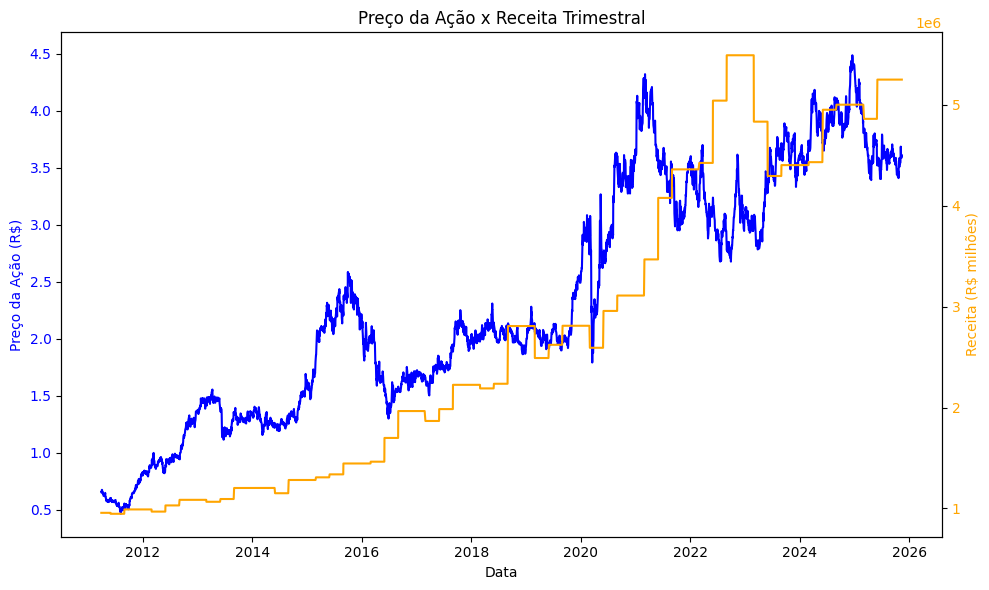

In [52]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Série 1 (ex: preço da ação)
ax1.plot(df_serie["Date"], df_serie["Adj Close"], color="blue", label="Preço (Adj Close)")
ax1.set_ylabel("Preço da Ação (R$)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Cria um segundo eixo Y (compartilha o eixo X)
ax2 = ax1.twinx()

# Série 2 (ex: receita)
ax2.plot(df_serie["Date"], df_serie["receita"], color="orange", label="Receita")
ax2.set_ylabel("Receita (R$ milhões)", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# Ajustes gerais
ax1.set_xlabel("Data")
plt.title("Preço da Ação x Receita Trimestral")
fig.tight_layout()

plt.show()
